# Salifort Motors Employee Attrition Prediction

**Google Advanced Data Analytics Certificate – Capstone Project**

## Business scenario
Salifort Motors is experiencing a high rate of employee turnover. The HR department collected employee survey data and asked for a data-driven analysis to understand what is driving attrition and how the company can improve retention.

## Project goal
The goal of this project is to analyze employee survey data and build classification models that predict whether an employee is likely to leave the company. The insights will help HR and senior leadership take earlier, more targeted action to improve employee retention.


## PACE: Plan

**Stakeholders**  
The main stakeholders are the HR department and Salifort Motors' senior leadership team. HR needs insights to better understand employee turnover, and leadership needs data-driven recommendations to improve retention, employee satisfaction, and workforce planning.

**Business problem**  
The company wants to understand what factors are associated with employee attrition and whether a predictive model can help identify employees who are at risk of leaving.

**Initial observations**  
The dataset contains employee-level information related to satisfaction, performance, workload, tenure, workplace incidents, promotion history, department, and salary. The target variable, `left`, is binary, so this is a supervised classification problem.

**Resources used**  
- Pandas documentation: https://pandas.pydata.org/docs/
- NumPy documentation: https://numpy.org/doc/
- Matplotlib documentation: https://matplotlib.org/stable/
- Seaborn documentation: https://seaborn.pydata.org/
- Scikit-learn documentation: https://scikit-learn.org/stable/

**Ethical considerations**  
Employee data should be handled carefully because model outputs can influence workplace decisions and employees' careers. The model should be used to support employees and improve retention, not to unfairly label or penalize individuals.


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')


In [2]:
# Load dataset
# For GitHub, keep HR_capstone_dataset.csv in the same repository folder as this notebook.
df0 = pd.read_csv('HR_capstone_dataset.csv')

print('Shape:', df0.shape)
df0.head()


Shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Data overview
df0.info()
print('Descriptive statistics:')
display(df0.describe())
print('Column names:')
list(df0.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
Descriptive statistics:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Column names:


['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years',
 'Department',
 'salary']

In [4]:
# Rename columns
df0 = df0.rename(columns={
    'average_montly_hours': 'average_monthly_hours',
    'Work_accident': 'work_accident',
    'Department': 'department'
})

list(df0.columns)


['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_monthly_hours',
 'time_spend_company',
 'work_accident',
 'left',
 'promotion_last_5years',
 'department',
 'salary']

In [5]:
# Check missing values and duplicates
print('Missing values by column:')
display(df0.isna().sum())
print('Duplicate rows:', df0.duplicated().sum())


Missing values by column:


satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

Duplicate rows: 3008


In [6]:
# Remove duplicate rows
df1 = df0.drop_duplicates(keep='first').copy()
print('Original shape:', df0.shape)
print('Deduplicated shape:', df1.shape)
df1.head()


Original shape: (14999, 10)
Deduplicated shape: (11991, 10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Potential outliers in time_spend_company: 824


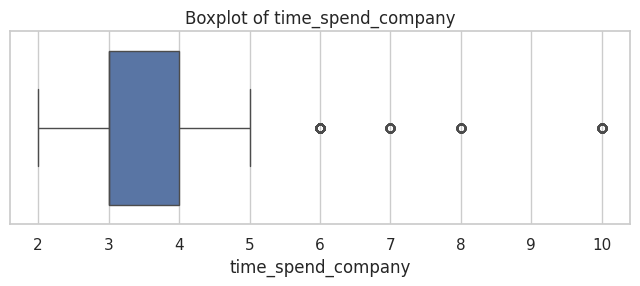

In [7]:
# Outlier check for time_spend_company using IQR
Q1 = df1['time_spend_company'].quantile(0.25)
Q3 = df1['time_spend_company'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df1[(df1['time_spend_company'] < lower_bound) | (df1['time_spend_company'] > upper_bound)]
print('Potential outliers in time_spend_company:', outliers.shape[0])

plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df1['time_spend_company'])
plt.title('Boxplot of time_spend_company')
plt.show()


## PACE: Analyze

**Observed relationships**  
The early patterns suggest that employee turnover is associated with satisfaction, workload, and tenure. Employees with lower satisfaction, more projects, longer monthly hours, and more years at the company appear more likely to leave.

**Distributions**  
The dataset contains a mix of continuous, discrete, and categorical variables. The target variable `left` is somewhat imbalanced, with more employees staying than leaving.

**Transformations**  
I standardized column names, corrected misspellings, and removed duplicate rows to avoid biasing the analysis. I did not remove outliers because tree-based models are generally less sensitive to them.

**Why EDA matters before modeling**  
EDA helps identify data-quality issues, understand feature behavior, reveal patterns related to the target variable, and guide model selection and interpretation.


In [8]:
# Attrition counts and percentages
turnover_counts = df1['left'].value_counts()
turnover_percentages = df1['left'].value_counts(normalize=True) * 100

print('Counts:')
display(turnover_counts)
print('Percentages:')
display(turnover_percentages)


Counts:


left
0    10000
1     1991
Name: count, dtype: int64

Percentages:


left
0    83.39588
1    16.60412
Name: proportion, dtype: float64

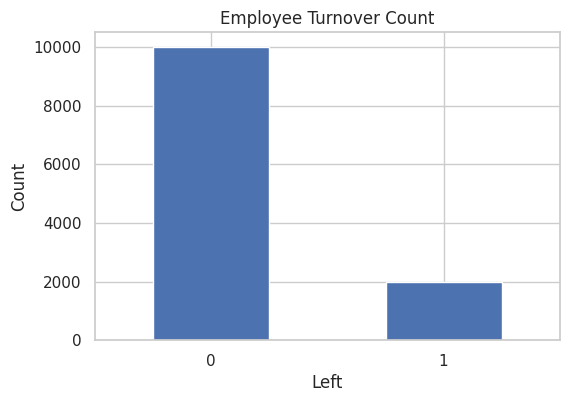

In [9]:
# Employee Turnover Count
df1['left'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.title('Employee Turnover Count')
plt.xlabel('Left')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

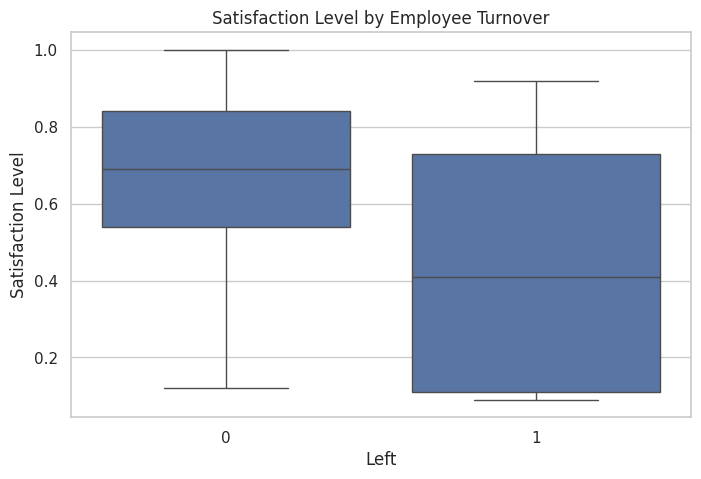

In [10]:
# Satisfaction Level by Employee Turnover
plt.figure(figsize=(8,5))
sns.boxplot(x='left', y='satisfaction_level', data=df1)
plt.title('Satisfaction Level by Employee Turnover')
plt.xlabel('Left')
plt.ylabel('Satisfaction Level')
plt.show()

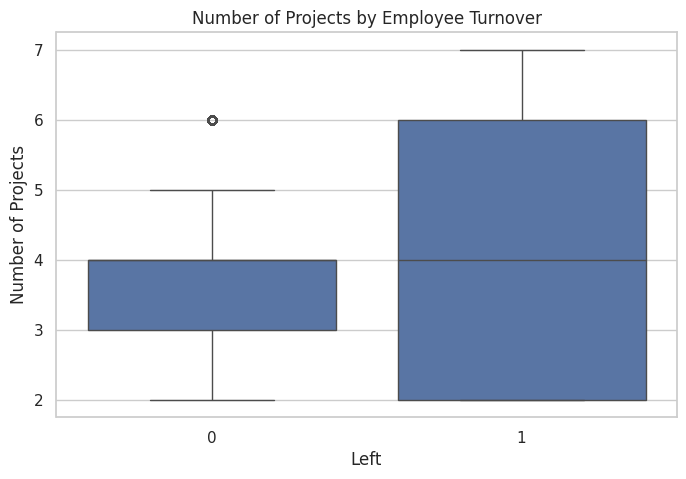

In [11]:
# Number of Projects by Employee Turnover
plt.figure(figsize=(8,5))
sns.boxplot(x='left', y='number_project', data=df1)
plt.title('Number of Projects by Employee Turnover')
plt.xlabel('Left')
plt.ylabel('Number of Projects')
plt.show()

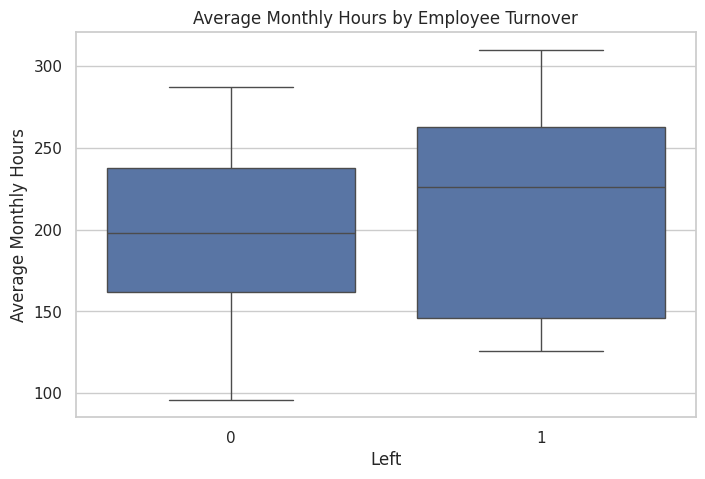

In [12]:
# Average Monthly Hours by Employee Turnover
plt.figure(figsize=(8,5))
sns.boxplot(x='left', y='average_monthly_hours', data=df1)
plt.title('Average Monthly Hours by Employee Turnover')
plt.xlabel('Left')
plt.ylabel('Average Monthly Hours')
plt.show()

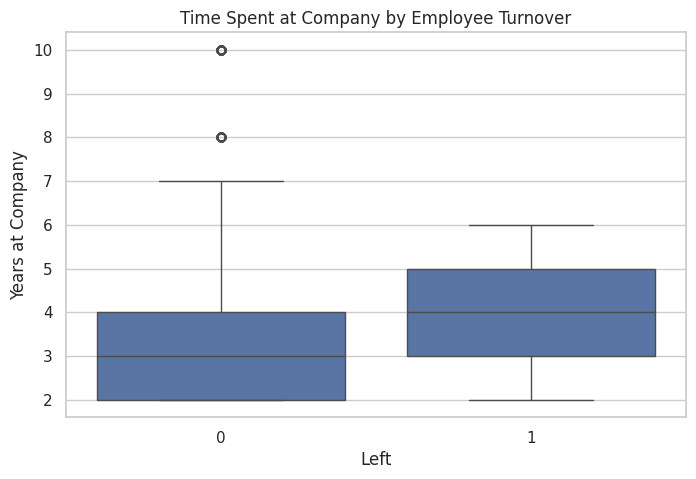

In [13]:
# Time Spent at Company by Employee Turnover
plt.figure(figsize=(8,5))
sns.boxplot(x='left', y='time_spend_company', data=df1)
plt.title('Time Spent at Company by Employee Turnover')
plt.xlabel('Left')
plt.ylabel('Years at Company')
plt.show()

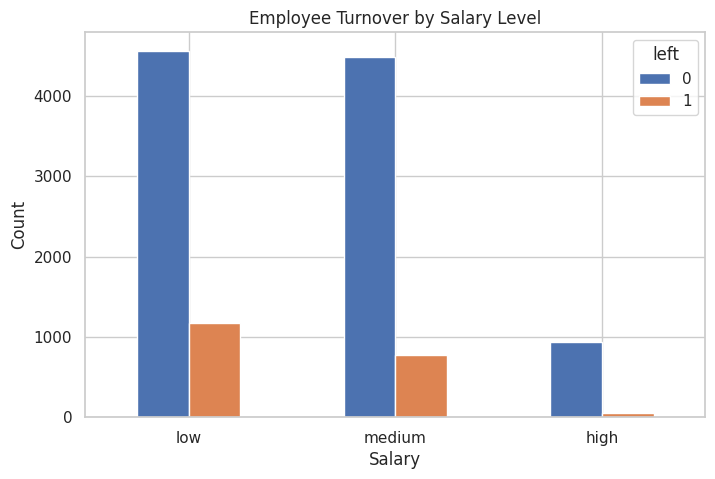

In [14]:
# Employee Turnover by Salary Level
pd.crosstab(df1['salary'], df1['left']).reindex(['low', 'medium', 'high']).plot(kind='bar', figsize=(8,5))
plt.title('Employee Turnover by Salary Level')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

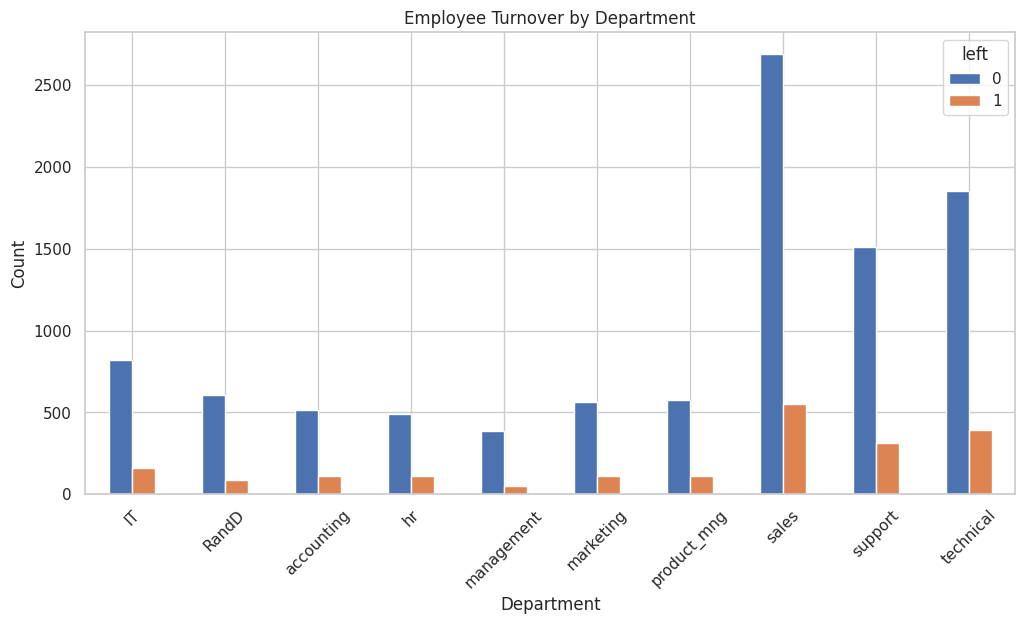

In [15]:
# Employee Turnover by Department
pd.crosstab(df1['department'], df1['left']).plot(kind='bar', figsize=(12,6))
plt.title('Employee Turnover by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

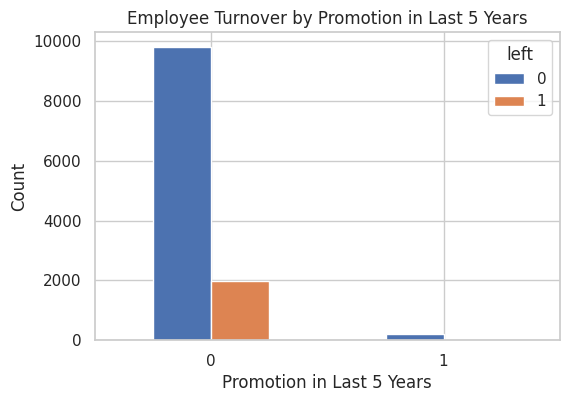

In [16]:
# Employee Turnover by Promotion in Last 5 Years
pd.crosstab(df1['promotion_last_5years'], df1['left']).plot(kind='bar', figsize=(6,4))
plt.title('Employee Turnover by Promotion in Last 5 Years')
plt.xlabel('Promotion in Last 5 Years')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Key EDA insights
- Employee attrition is the minority class, but still large enough for classification modeling.
- Employees who left generally reported **lower satisfaction** than employees who stayed.
- Employees who left tended to have **more projects**, **more monthly hours**, and **longer tenure**.
- Turnover appears more common among employees with **low** and **medium** salary levels than among employees with **high** salaries.
- Promotions are rare overall, but employees who were promoted seem less likely to leave.


## PACE: Construct

**Prediction task**  
This is a supervised **binary classification** task because the target variable `left` has two possible outcomes: the employee either stayed (`0`) or left (`1`).

**Model choice**  
Tree-based classification models are appropriate for this task because they can capture nonlinear relationships, handle interactions between variables, and work well with numerical and encoded categorical features.

**Assumptions and considerations**  
For tree-based models, strict linearity assumptions do not apply as they do for logistic regression. The dataset is large enough for modeling, the target variable is binary, and categorical variables can be handled through one-hot encoding. The target is somewhat imbalanced, so recall and F1-score are important evaluation metrics.


In [17]:
# Prepare data for modeling
df_model = df1.copy()
df_model = pd.get_dummies(df_model, columns=['department', 'salary'], drop_first=True)

X = df_model.drop(columns='left')
y = df_model['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)


X_train shape: (8993, 18)
X_test shape: (2998, 18)
y_train shape: (8993,)
y_test shape: (2998,)


In [18]:
# Decision Tree baseline
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('Decision Tree Performance')
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1:', f1_score(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_dt))
print('')
print(classification_report(y_test, y_pred_dt))


Decision Tree Performance
Accuracy: 0.9669779853235491
Precision: 0.8858800773694391
Recall: 0.9196787148594378
F1: 0.9024630541871921
ROC-AUC: 0.9480393574297188

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2500
           1       0.89      0.92      0.90       498

    accuracy                           0.97      2998
   macro avg       0.93      0.95      0.94      2998
weighted avg       0.97      0.97      0.97      2998



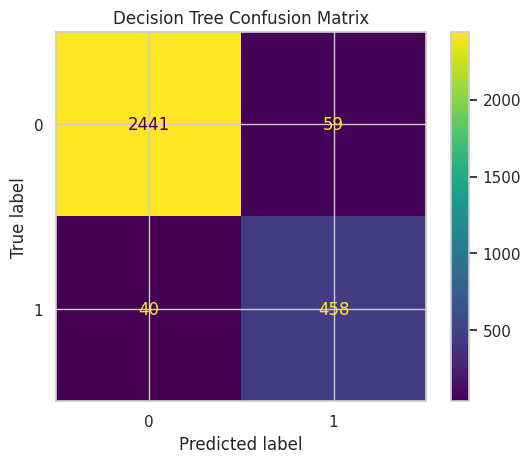

In [19]:
# Decision Tree confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt.classes_)
disp.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()


In [20]:
# Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest Performance')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1:', f1_score(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))
print('')
print(classification_report(y_test, y_pred_rf))


Random Forest Performance
Accuracy: 0.985657104736491
Precision: 0.9913606911447084
Recall: 0.9216867469879518
F1: 0.9552549427679501
ROC-AUC: 0.9784570281124496

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2500
           1       0.99      0.92      0.96       498

    accuracy                           0.99      2998
   macro avg       0.99      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



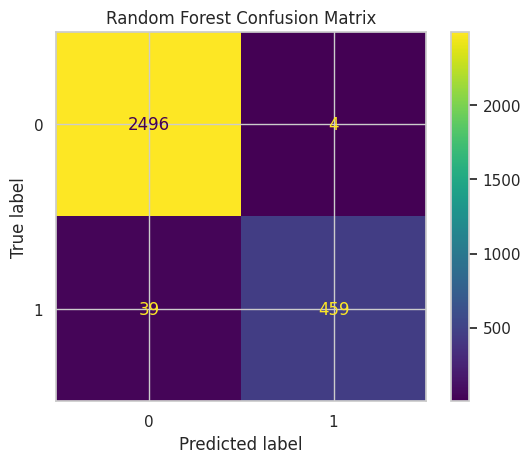

In [21]:
# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()


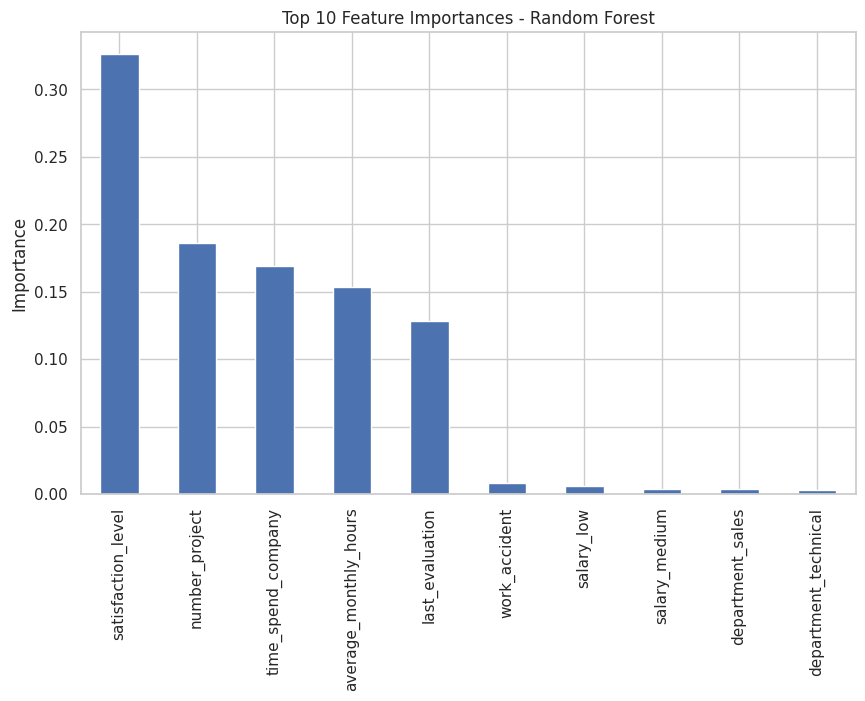

satisfaction_level       0.326285
number_project           0.185885
time_spend_company       0.168877
average_monthly_hours    0.153529
last_evaluation          0.127910
work_accident            0.007795
salary_low               0.005793
salary_medium            0.003573
department_sales         0.003408
department_technical     0.003227
dtype: float64

In [22]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.show()

importances.head(10)


## PACE: Execute

**Model comparison**  
Both models performed well, but the **Random Forest** model achieved the strongest overall performance and is the recommended final model.

**Decision Tree results**  
- Accuracy: **0.9670**
- Precision: **0.8859**
- Recall: **0.9197**
- F1-score: **0.9025**
- ROC-AUC: **0.9480**

**Random Forest results**  
- Accuracy: **0.9857**
- Precision: **0.9914**
- Recall: **0.9217**
- F1-score: **0.9553**
- ROC-AUC: **0.9785**

**Most important predictors**  
The Random Forest model identified the top attrition drivers as:
1. `satisfaction_level`
2. `number_project`
3. `time_spend_company`
4. `average_monthly_hours`
5. `last_evaluation`


## Business recommendations
- Monitor employees with **low satisfaction**, **heavy workload**, and **longer tenure**, as these patterns are strongly associated with turnover.
- Review project allocation and long working hours to reduce overwork risk.
- Strengthen retention strategies for employees who may be disengaged or overloaded.
- Review career development pathways and promotion opportunities.
- Use model outputs to support employee wellbeing and retention planning, not to penalize individuals.


## Limitations
- The dataset contains survey-style and operational variables, but it does not include other potentially useful factors such as manager relationships, remote work conditions, benefits, or training participation.
- The analysis is based on historical data and cannot establish causation.
- The model should be monitored over time because workforce patterns and turnover drivers can change.


## Final conclusion
The Random Forest model was the best-performing model and showed that employee turnover at Salifort Motors is most strongly associated with **low satisfaction, heavy workload, and longer tenure**. These findings can help leadership take earlier, more targeted action to improve retention.
